# Тойота Королла

### Иследование линейной регрессии

| Признак | Описание |
|---|---|
| Id | Уникальный идентификатор |
| Model | Модель автомобиля |
| Price | Цена (целевая переменная) |
| Age_08_04 | Возраст автомобиля в месяцах (на апрель 2004) |
| Mfg_Month | Месяц производства |
| Mfg_Year | Год производства |
| KM | Пробег в километрах |
| Fuel_Type | Тип топлива |
| HP | Мощность в лошадиных силах |
| Met_Color | Металлик цвет (0/1) |
| Color | Цвет кузова |
| Automatic | Автоматическая коробка (0/1) |
| CC | Объём двигателя в куб. см |
| Doors | Количество дверей |
| Cylinders | Количество цилиндров |
| Gears | Количество передач |
| Quarterly_Tax | Квартальный налог |
| Weight | Вес автомобиля |
| Mfr_Guarantee | Гарантия производителя (0/1) |
| BOVAG_Guarantee | Гарантия BOVAG (0/1) |
| Guarantee_Period | Срок гарантии в месяцах |
| ABS | Антиблокировочная система (0/1) |
| Airbag_1 | Подушка безопасности водителя (0/1) |
| Airbag_2 | Подушка безопасности пассажира (0/1) |
| Airco | Кондиционер (0/1) |
| Automatic_airco | Автоматический кондиционер (0/1) |
| Boardcomputer | Бортовой компьютер (0/1) |
| CD_Player | CD плеер (0/1) |
| Central_Lock | Центральный замок (0/1) |
| Powered_Windows | Электростёкла (0/1) |
| Power_Steering | Усилитель руля (0/1) |
| Radio | Радио (0/1) |
| Mistlamps | Противотуманные фары (0/1) |
| Sport_Model | Спортивная модель (0/1) |
| Backseat_Divider | Разделитель заднего сиденья (0/1) |
| Metallic_Rim | Металлические диски (0/1) |
| Radio_cassette | Кассетная магнитола (0/1) |
| Parking_Assistant | Парктроник (0/1) |
| Tow_Bar | Фаркоп (0/1) |

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor


# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

# 1. Загрузка данных
print("1. Загрузка данных")
df = pd.read_csv('ToyotaCorolla.csv')

1. Загрузка данных


## EDA

In [190]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

Пропусков нет

In [191]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

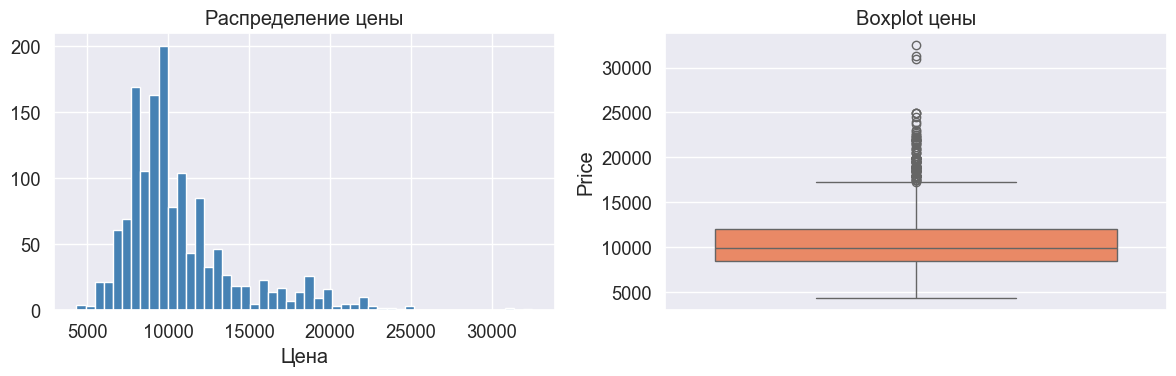

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price'], bins=50, color='steelblue')
axes[0].set_title('Распределение цены')
axes[0].set_xlabel('Цена')

sns.boxplot(y=df['Price'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot цены')

plt.tight_layout()
plt.show()

Большинство цен в промежутке 7000-15000 и длинные хвост вправо

In [193]:
corr = df.corr(numeric_only=True)['Price'].abs().sort_values(ascending=False)
print(corr)

Price                1.000000
Mfg_Year             0.885159
Age_08_04            0.876590
Id                   0.738250
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
KM                   0.569960
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Tow_Bar              0.172369
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Radio_cassette       0.043179
Radio                0.041887
Automatic            0.033081
BOVAG_Guar

Делаем One-Hot Encoding категориальных признаков

In [194]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

### Удаляем ненужные столбцы:
1. Id, Model - не несут полезной информации
2. Cylinders - одно и то же значение
3. Mfg_Year — дублирует Age_08_04
4. Color - не должен влиять не цену
4. Удаляем признаки у которых корреляция с ценой ниже 0.3

In [197]:
df = df.drop(columns=['Id', 'Model', 'Color', 'Mfg_Year', 'Cylinders'])
df_trees = df
df = df.drop(columns=(corr[corr < 0.3].index))

### Feature engineering

In [198]:
df['Age_KM'] = df['Age_08_04'] * df['KM']

In [199]:
print(df.info())
print(df_trees.info())

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Price             1436 non-null   int64
 1   Age_08_04         1436 non-null   int64
 2   KM                1436 non-null   int64
 3   HP                1436 non-null   int64
 4   Weight            1436 non-null   int64
 5   ABS               1436 non-null   int64
 6   Airco             1436 non-null   int64
 7   Automatic_airco   1436 non-null   int64
 8   Boardcomputer     1436 non-null   int64
 9   CD_Player         1436 non-null   int64
 10  Central_Lock      1436 non-null   int64
 11  Powered_Windows   1436 non-null   int64
 12  Fuel_Type_Diesel  1436 non-null   bool 
 13  Fuel_Type_Petrol  1436 non-null   bool 
 14  Age_KM            1436 non-null   int64
dtypes: bool(2), int64(13)
memory usage: 148.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 3

## Разделение на train/test и обучение

### Линейная регрессия

In [200]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [201]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'{name}: RMSE={rmse:.0f}, MAE={mae:.0f}, R²={r2:.3f}')

LinearRegression: RMSE=1228, MAE=867, R²=0.887
Ridge: RMSE=1230, MAE=867, R²=0.887
Lasso: RMSE=1229, MAE=867, R²=0.887


In [202]:
params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

ridge_grid = GridSearchCV(Ridge(), params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

lasso_grid = GridSearchCV(Lasso(max_iter=10000), params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

print('Ridge лучший alpha:', ridge_grid.best_params_, '| R²:', round(ridge_grid.best_score_, 3))
print('Lasso лучший alpha:', lasso_grid.best_params_, '| R²:', round(lasso_grid.best_score_, 3))

Ridge лучший alpha: {'alpha': 0.1} | R²: 0.886
Lasso лучший alpha: {'alpha': 1} | R²: 0.886


Оценка упала, но она более правдивая, сделанная с кросс-валидацией

In [203]:
best_models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=ridge_grid.best_params_['alpha']),
    'Lasso (alpha=10)': Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000)
}

for name, model in best_models.items():
    model.fit(X_train_scaled, y_train)

    y_pred_lg = model.predict(X_test_scaled)
    
    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_r2 = r2_score(y_test, y_pred_lg)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_lg))
    
    print(f'{name}: Train R²={train_r2:.3f} | Test R²={test_r2:.3f} | RMSE={rmse:.0f}')

LinearRegression: Train R²=0.895 | Test R²=0.887 | RMSE=1228
Ridge (alpha=10): Train R²=0.895 | Test R²=0.887 | RMSE=1228
Lasso (alpha=10): Train R²=0.895 | Test R²=0.887 | RMSE=1229


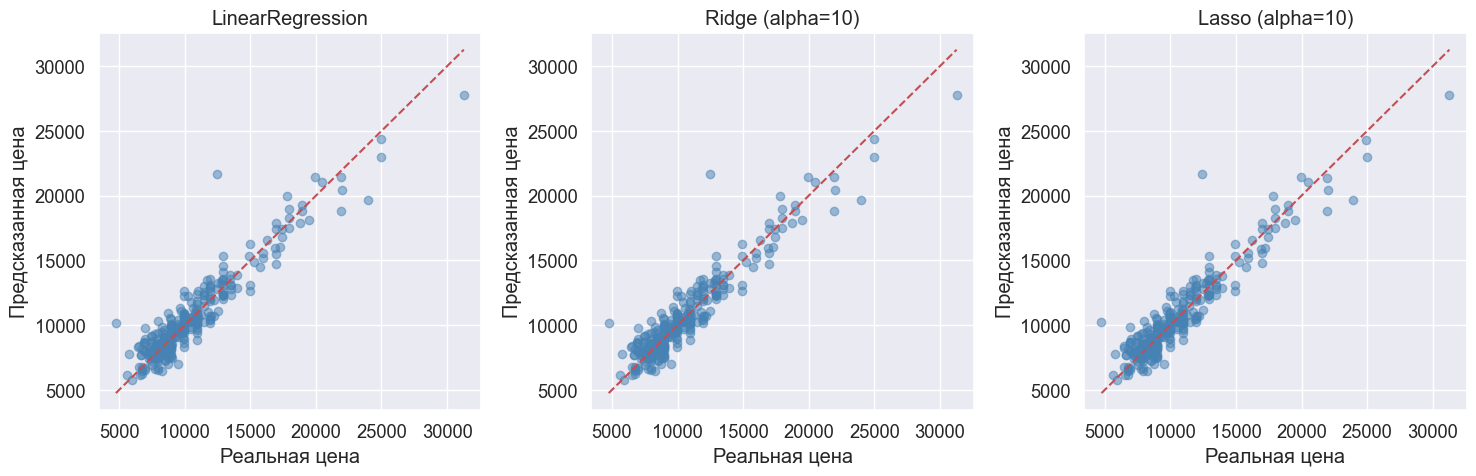

In [204]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test_scaled)
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel('Реальная цена')
    ax.set_ylabel('Предсказанная цена')
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Лес

In [234]:
X = df_trees.drop(columns=['Price'])
y = df_trees['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'max_depth': range(1, 16),
    'n_estimators': [10, 50, 100, 200, 500]
}

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred_raw = model.predict(X_test)
print(r2_score(y_pred_raw, y_test))
model_cv = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1,scoring='neg_mean_squared_error')


0.9221205138420832


In [218]:
model_cv.fit(X_train, y_train)

best_depth = model_cv.best_params_['max_depth']
print(model_cv.best_params_)
print(model_cv.best_score_)

rf = model_cv.best_estimator_

y_pred_rf = rf.predict(X_test)

{'max_depth': 9, 'n_estimators': 500}
-1180716.6131185999


In [235]:
dt = DecisionTreeRegressor(random_state=42, max_depth=best_depth)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [236]:
print(f"R2 RF: {r2_score(y_test, y_pred_rf):.2f}")
print(f"R2 DT: {r2_score(y_test, y_pred_dt):.2f}")

R2 RF: 0.93
R2 DT: 0.89


1. Лес дольше обучается чем одно дерево (секунда на 100 деревье против доли секунды)
2. Мне кажется лес всегда будет медленнее чисто из логики, что обучается больше деревьев. Но если распараллелить процесс обучения, то одной скорости добиться можно
3. По метрике R2 0.93 против 0.89

## Сравнение моделей

In [237]:
def get_metrics(y_true, y_pred):
    return {
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2':    r2_score(y_true, y_pred)
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rf),   # no_scale
    get_metrics(y_test, y_pred_dt),   # with_scale
    get_metrics(y_test, y_pred_lg),   # best_grid
], index=['RF', 'DT', 'LinReg'])

display(results.round(4))

,MSE,RMSE,R2
RF,9.369421e+05,967.9577,0.9298
DT,1.505173e+06,1226.8548,0.8872
LinReg,1.509781e+06,1228.7314,0.8868


1. Больше использовал метрику R2, так как она более наглядная, возвращает от 0 до 1, где 1 - идеальная модель, поэтому по ней проще сравнивать. RMSE - это корень из MSE, то есть по сути средний разброс по угаданной цене, MAE очень похожа, только там модуль, а не квадраты и потом корень
2. Метрики считал на тестовых выборках очевидно
3. Случайный лес справился лучше. Одно дерево и линейная модель справились одинаково. Даже при использовании 10 деревьев вместо одного, оценка возрастает до 0.92, а при 100 и так далее деревьях 0.93, так что нет смысла много брать.
4. 0.93 думаю хороший результат